In [30]:
import pandas as pd
import sys
sys.path.append('/home/pulpo/Documents/quantitative-trading')

from src.quanttrading.data import prepare_data
from src.quanttrading.analysis import full_analysis

In [31]:
# DOWNLOAD DATA
df_aapl = prepare_data('AAPL', '1y','1d')
df_nvda = prepare_data('NVDA', '1y', '1d')
df_msft = prepare_data('MSFT', '1y', '1d')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


STATISTICS:
 mean:  0.137
 std:  1.473
 skew:  0.531
 kurt:  2.307

PERCENTILES:
  p05: -2.027
  p25: -0.594
  p75: 0.631
  p95: 2.921

OUTLIERS:
  Total data points: 250
  Outliers detected: 3
  Percentage: 1.20%

Plotting histogram...


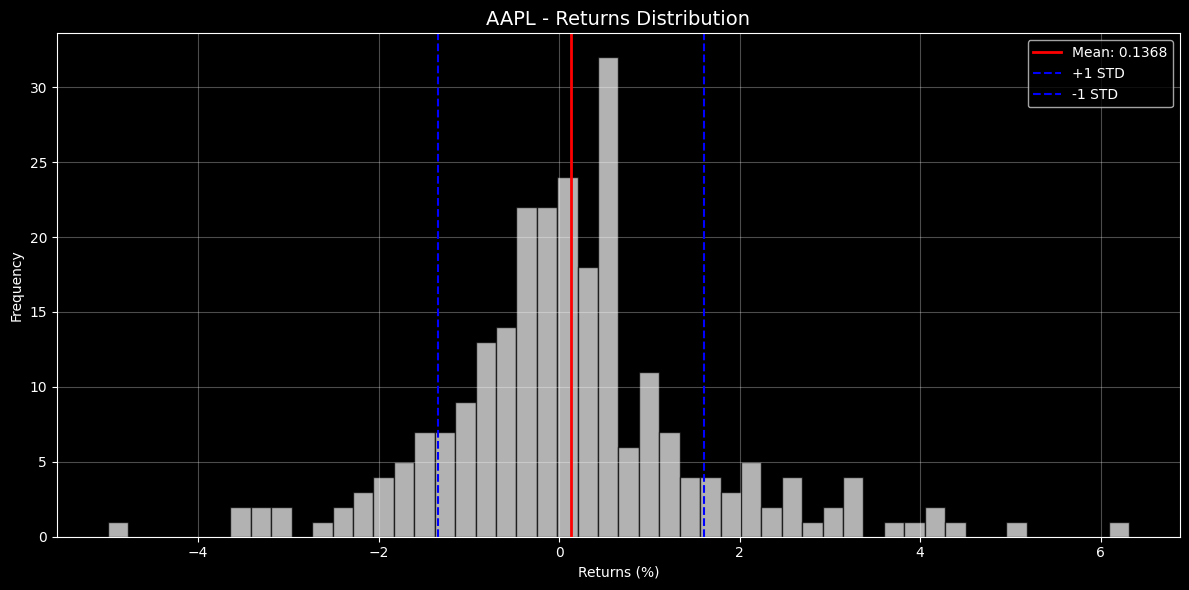

Plotting time series...


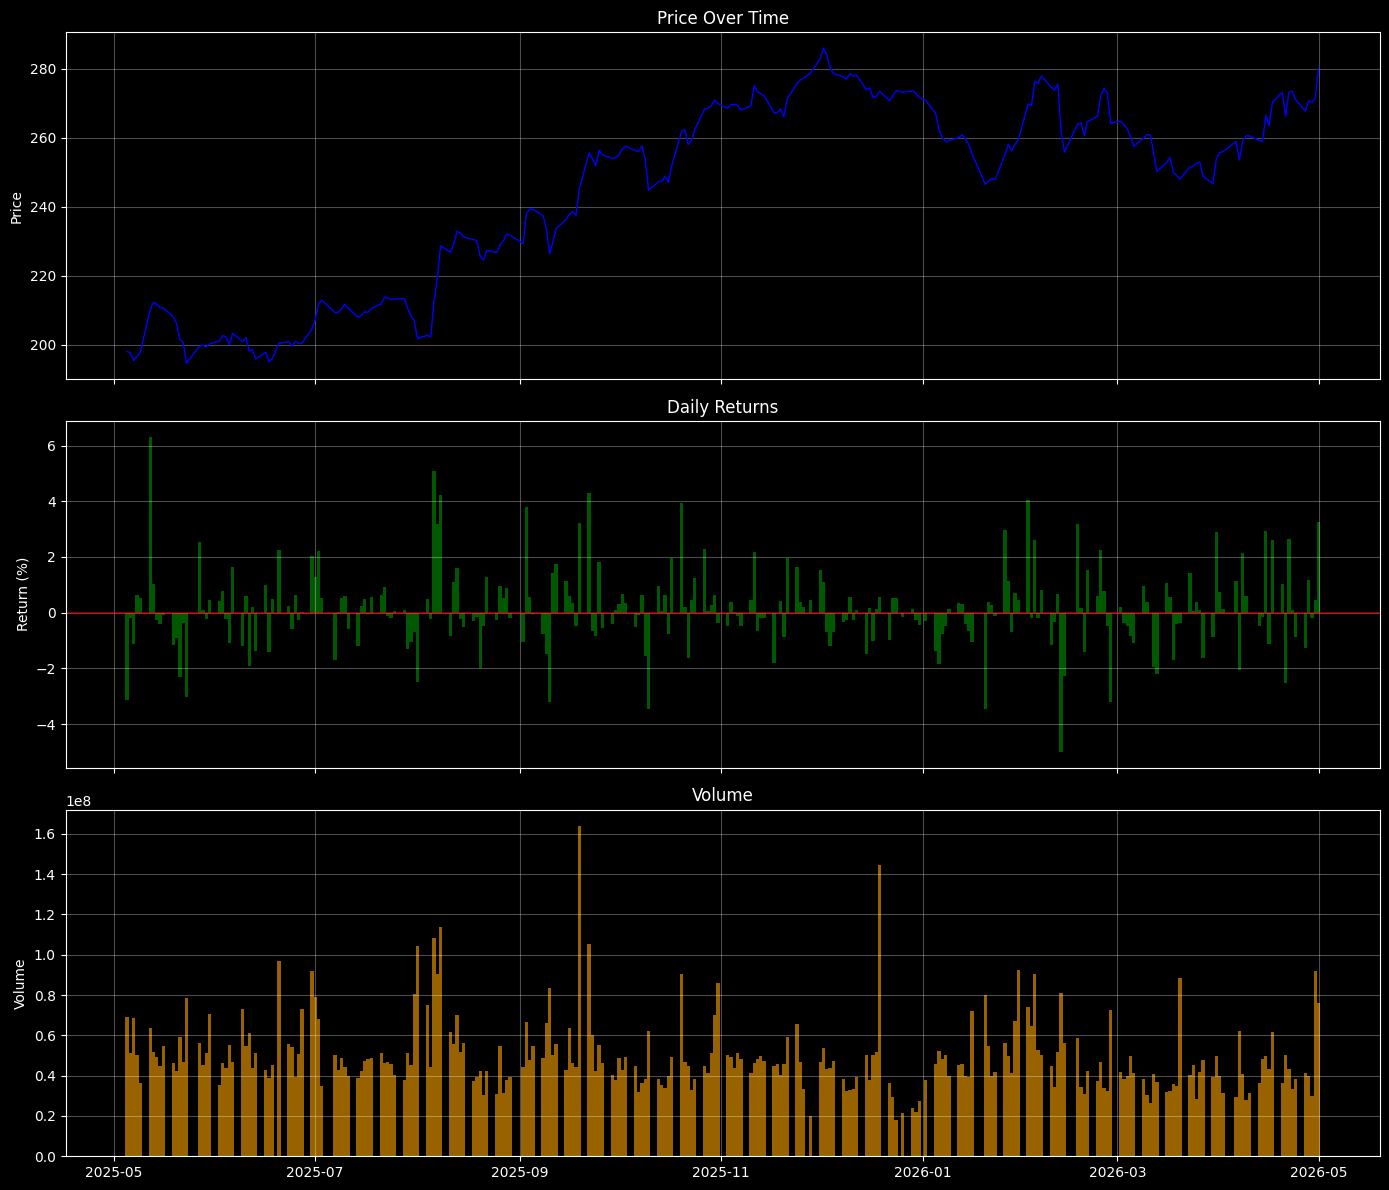

Plotting rolling statistics...


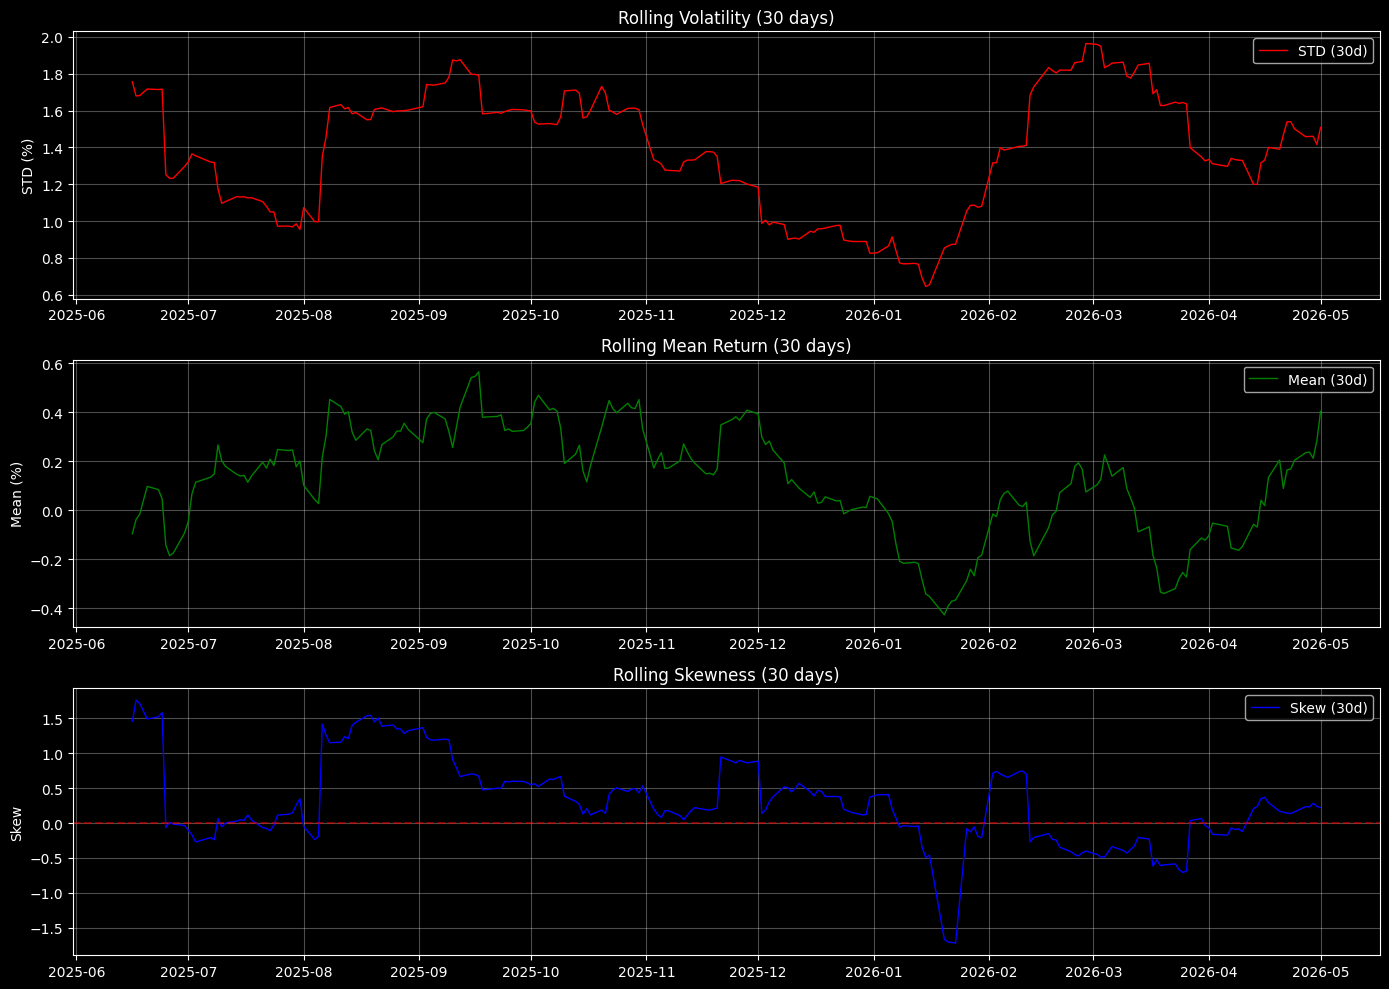

Plotting autocorrelation...


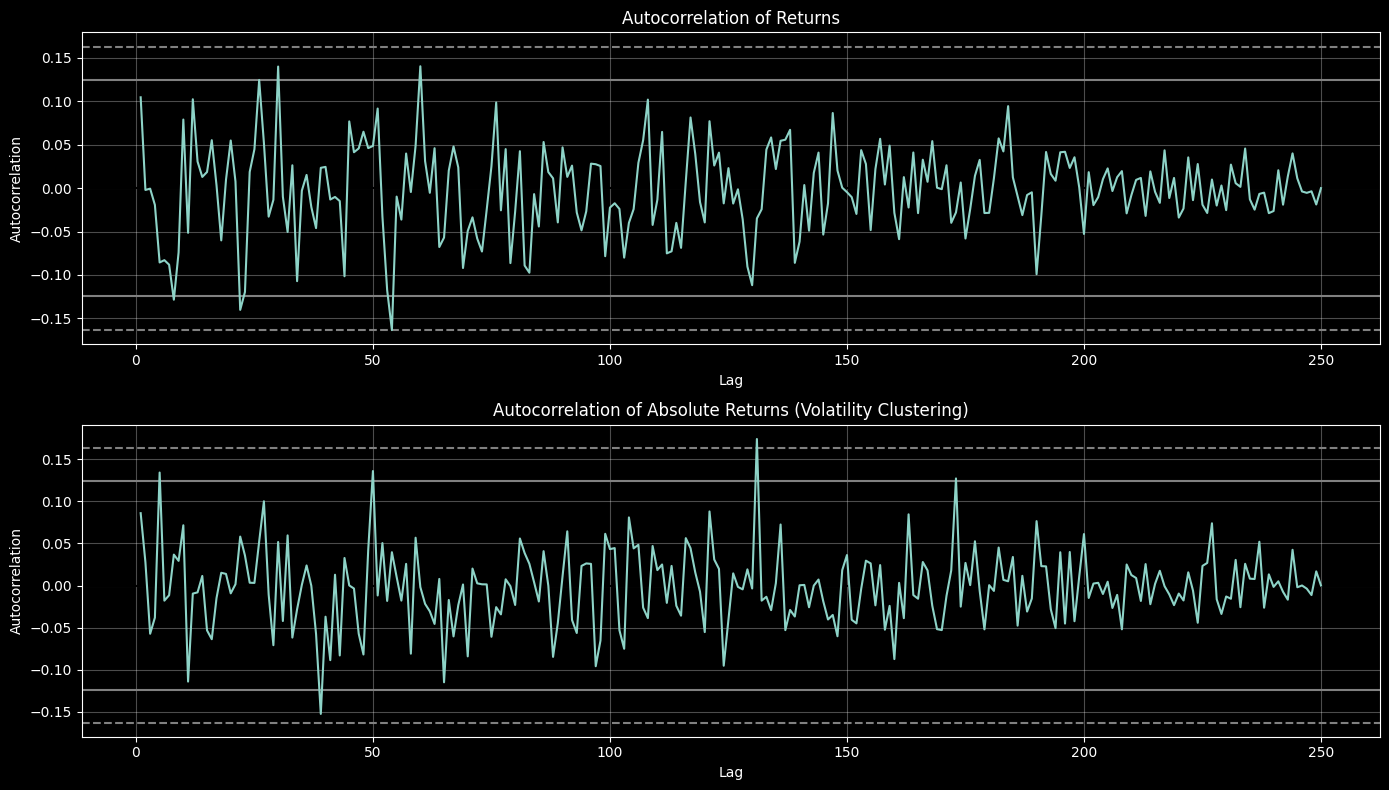


Outlier details (top 10):
Price         Return  Distance (STD)
Date                                
2025-05-12  6.314610        4.195037
2025-08-06  5.090676        3.363928
2026-02-12 -4.998181        3.486884




In [32]:
# ANALYSIS
results_aapl = full_analysis(df_aapl, 'AAPL', window=30, threshold=3)

STATISTICS:
 mean:  0.243
 std:  2.134
 skew:  0.119
 kurt:  0.529

PERCENTILES:
  p05: -3.372
  p25: -0.874
  p75: 1.576
  p95: 3.892

OUTLIERS:
  Total data points: 250
  Outliers detected: 1
  Percentage: 0.40%

Plotting histogram...


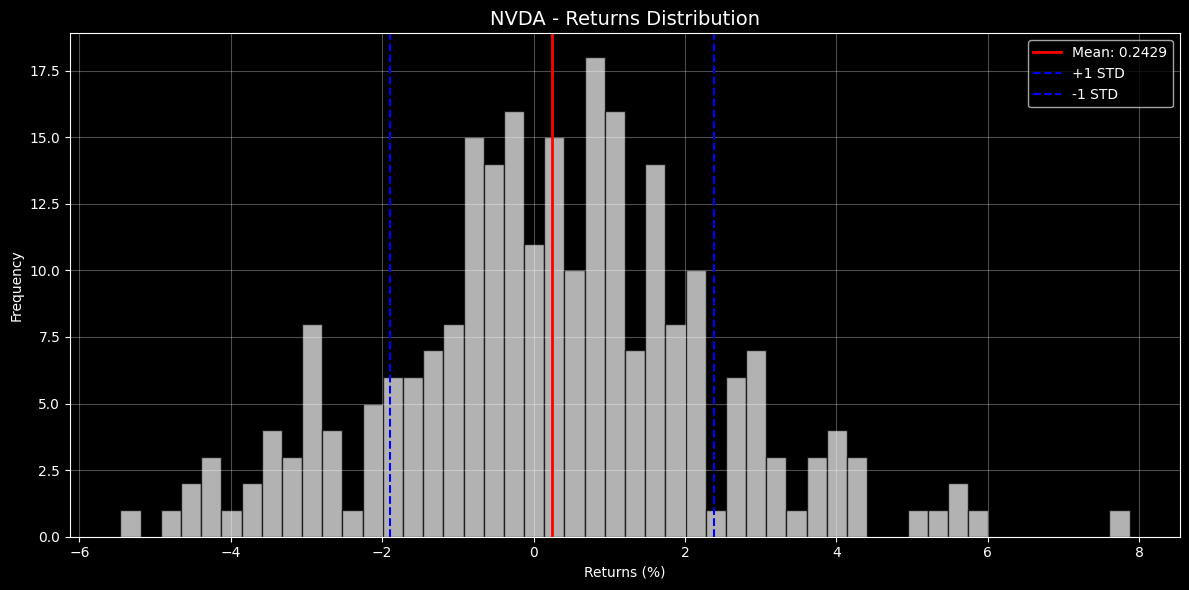

Plotting time series...


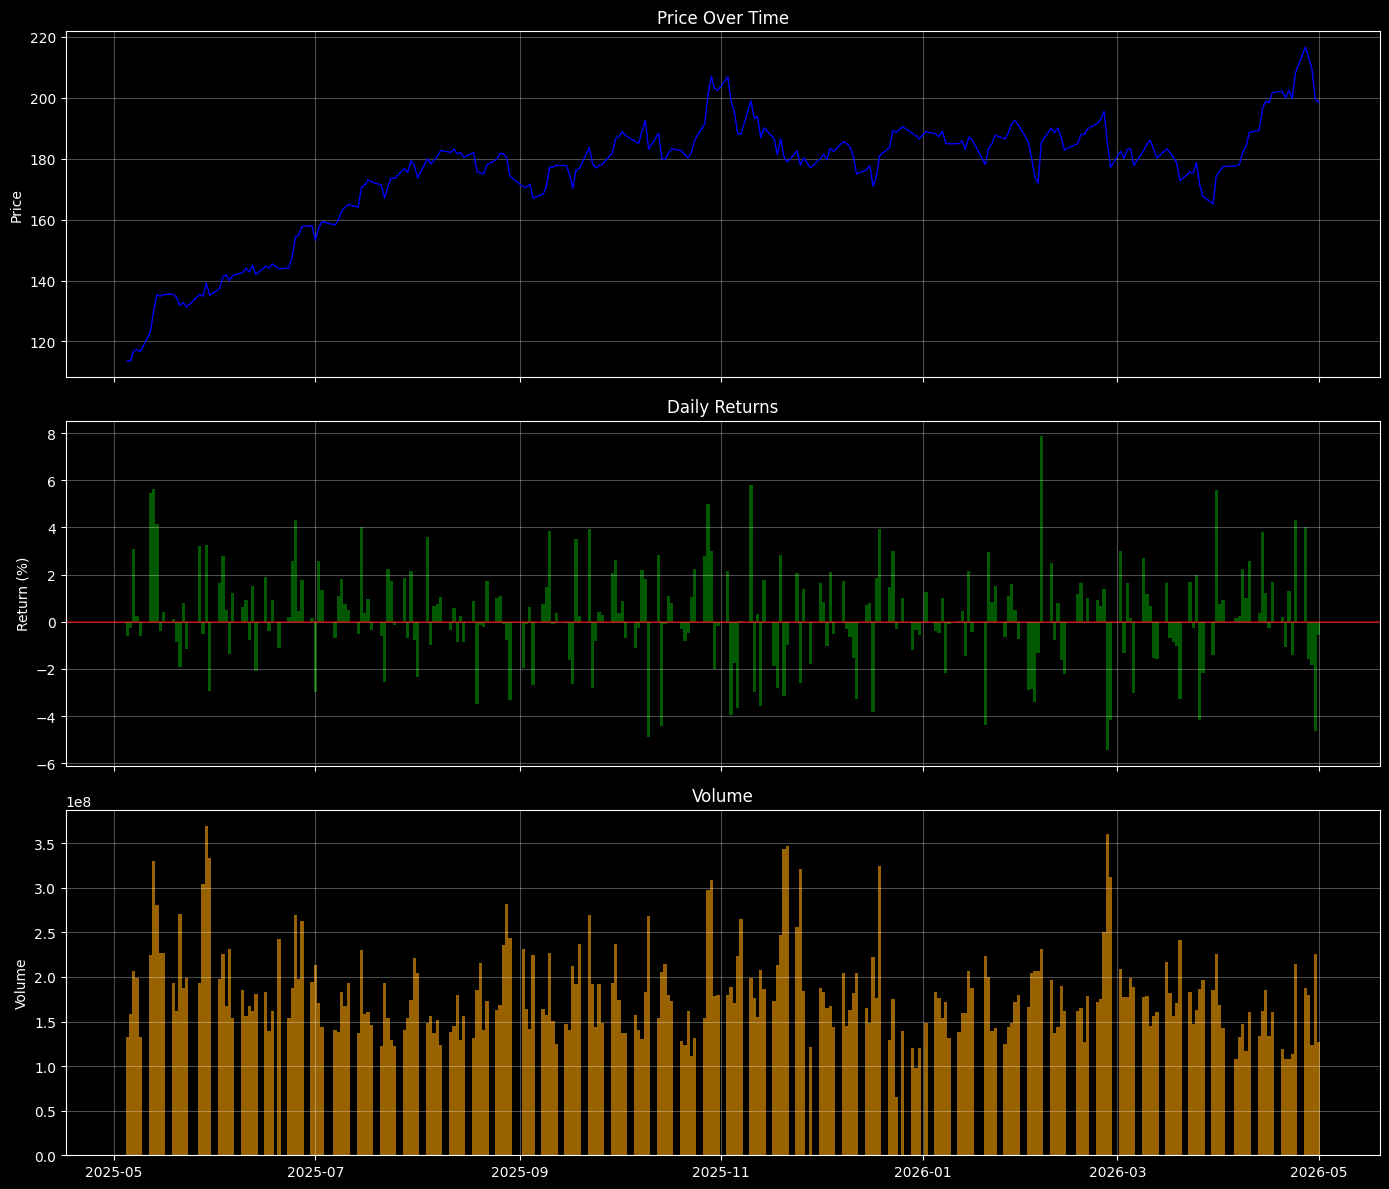

Plotting rolling statistics...


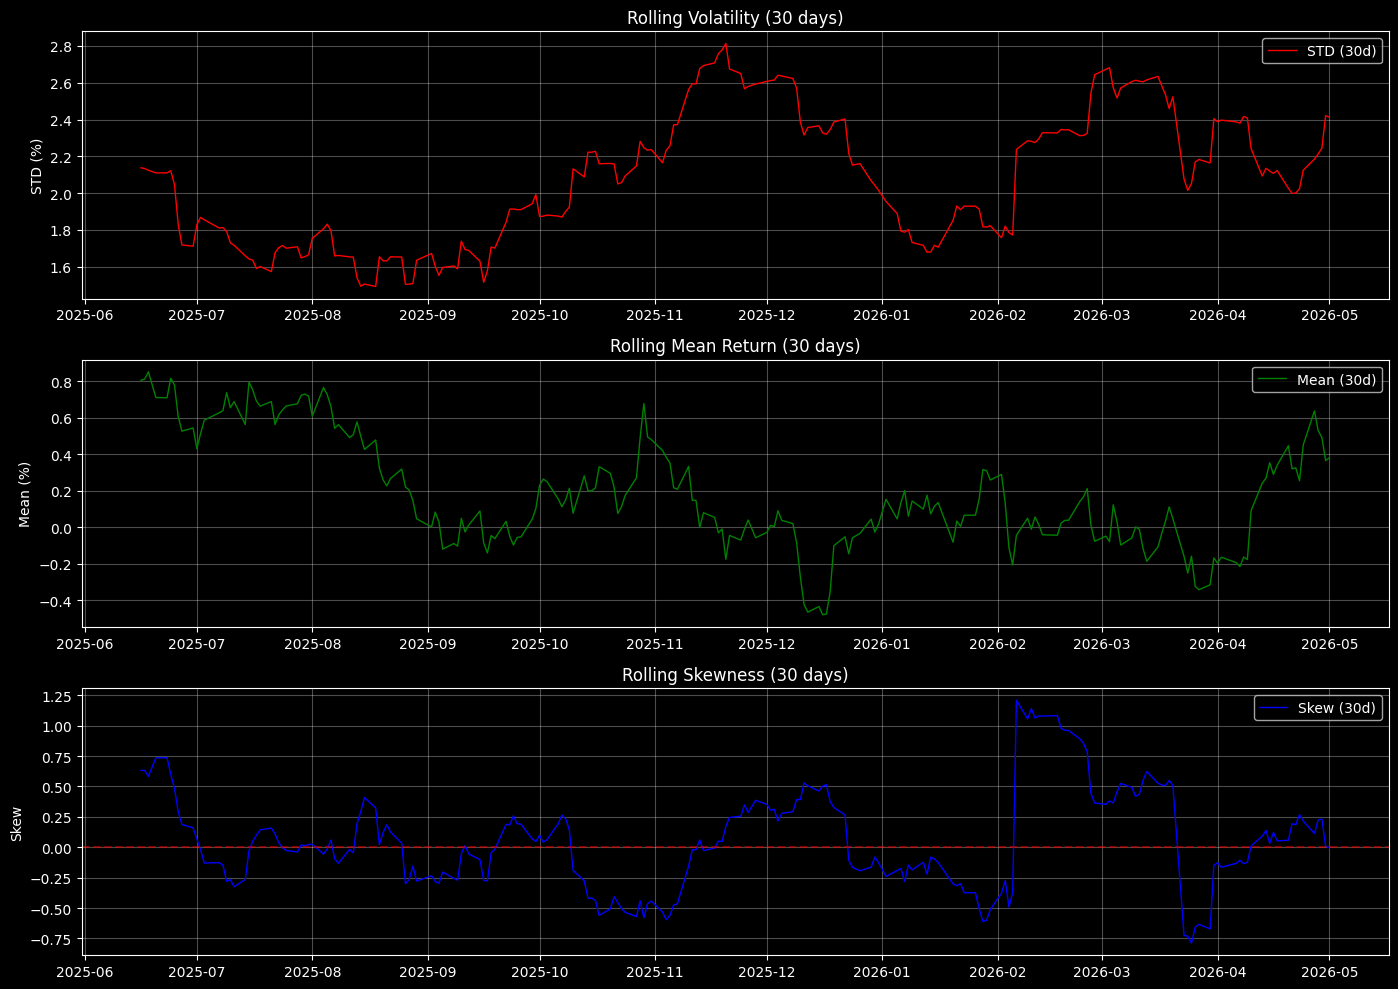

Plotting autocorrelation...


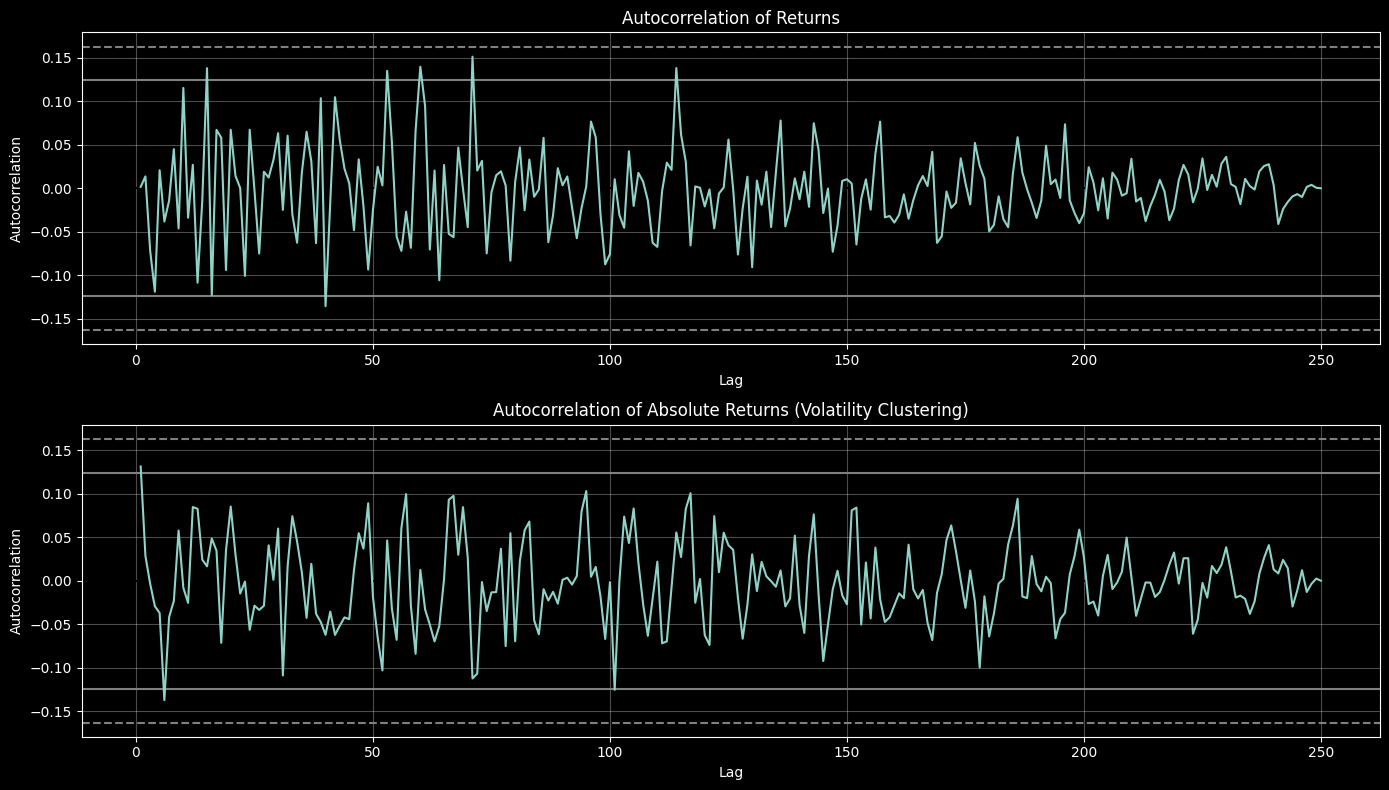


Outlier details (top 10):
Price        Return  Distance (STD)
Date                               
2026-02-06  7.87177        3.575168




In [33]:
results_nvda = full_analysis(df_nvda, 'NVDA', 30, 3)

STATISTICS:
 mean: -0.005
 std:  1.487
 skew: -1.275
 kurt:  8.331

PERCENTILES:
  p05: -2.457
  p25: -0.648
  p75: 0.651
  p95: 2.181

OUTLIERS:
  Total data points: 250
  Outliers detected: 3
  Percentage: 1.20%

Plotting histogram...


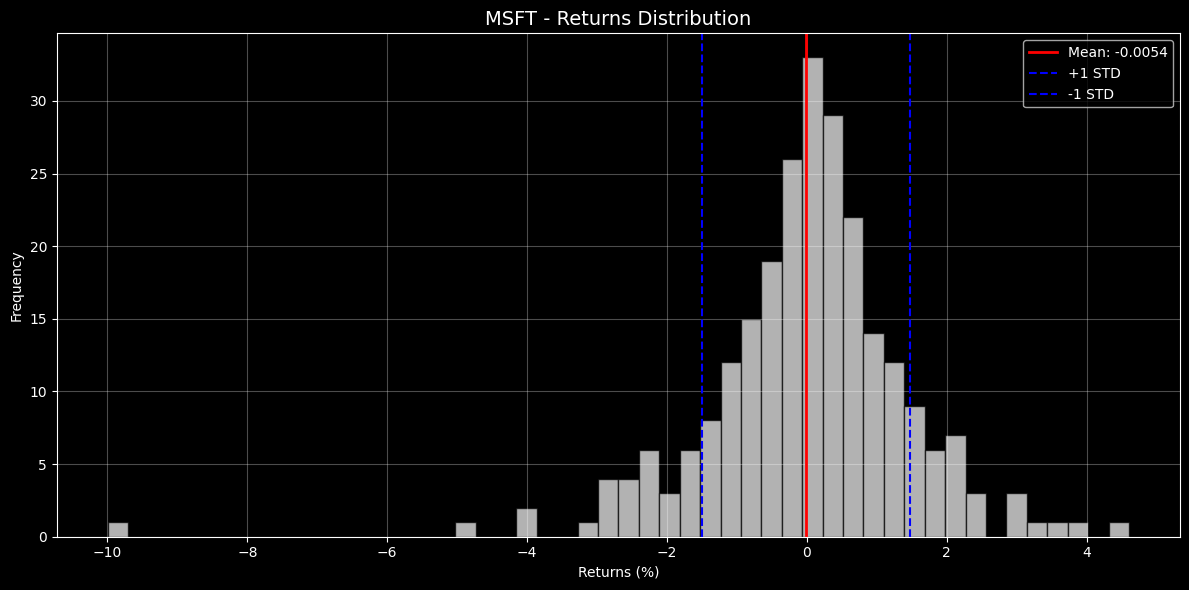

Plotting time series...


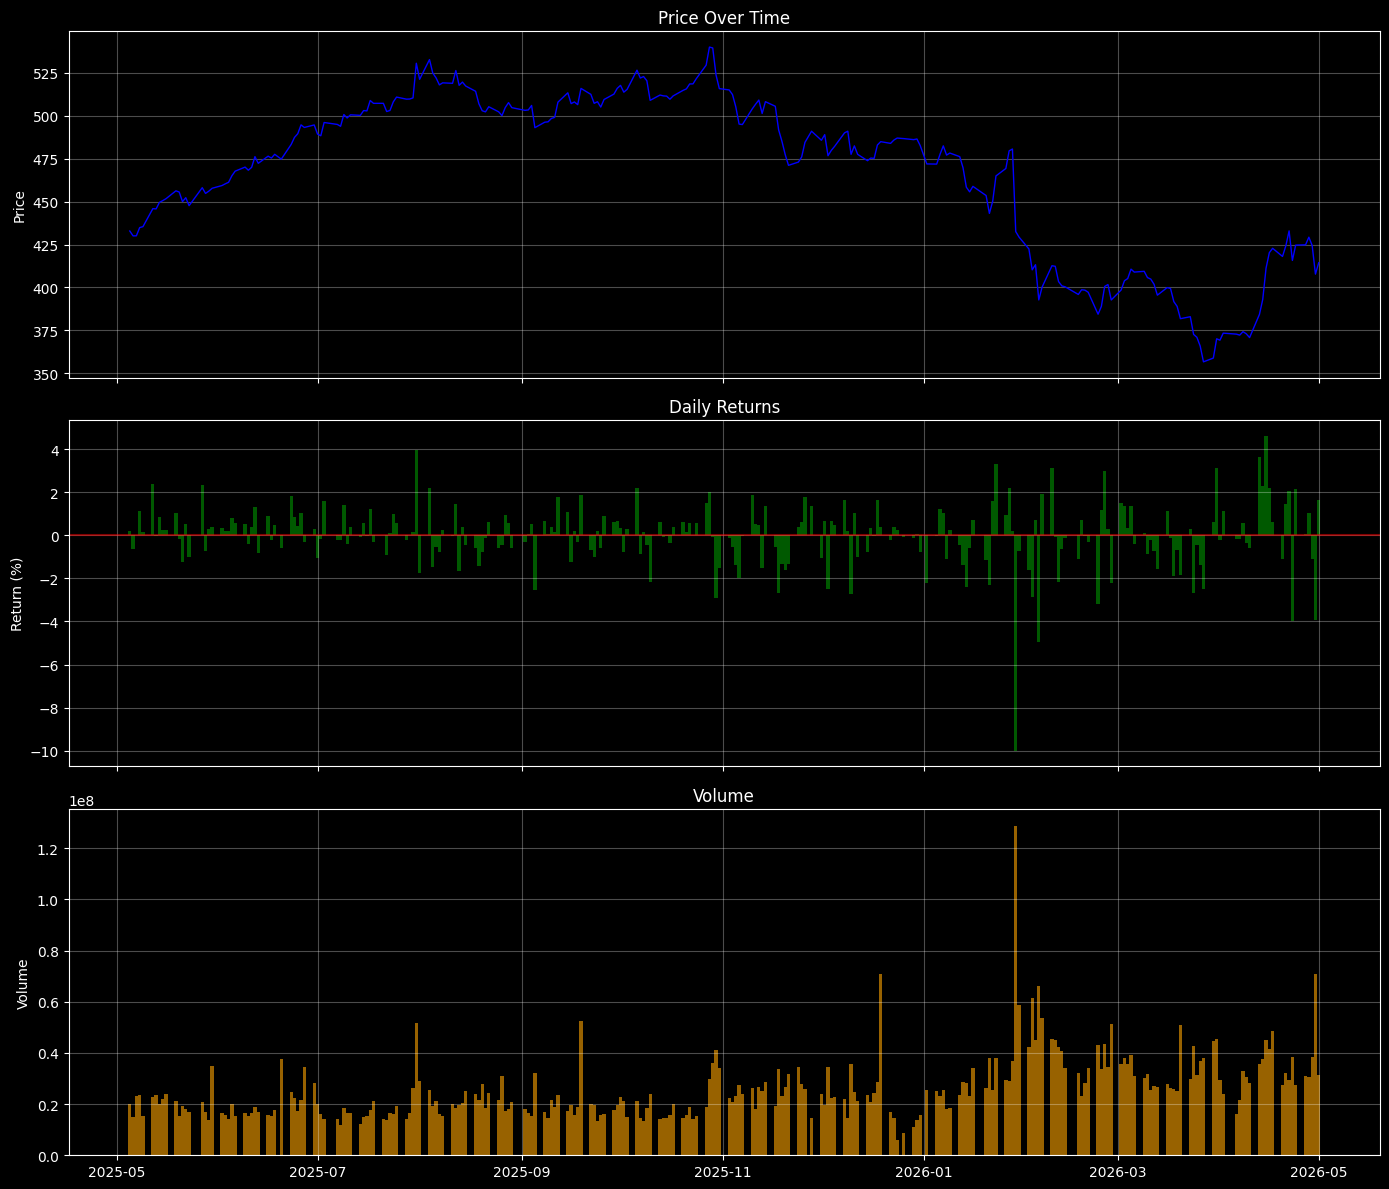

Plotting rolling statistics...


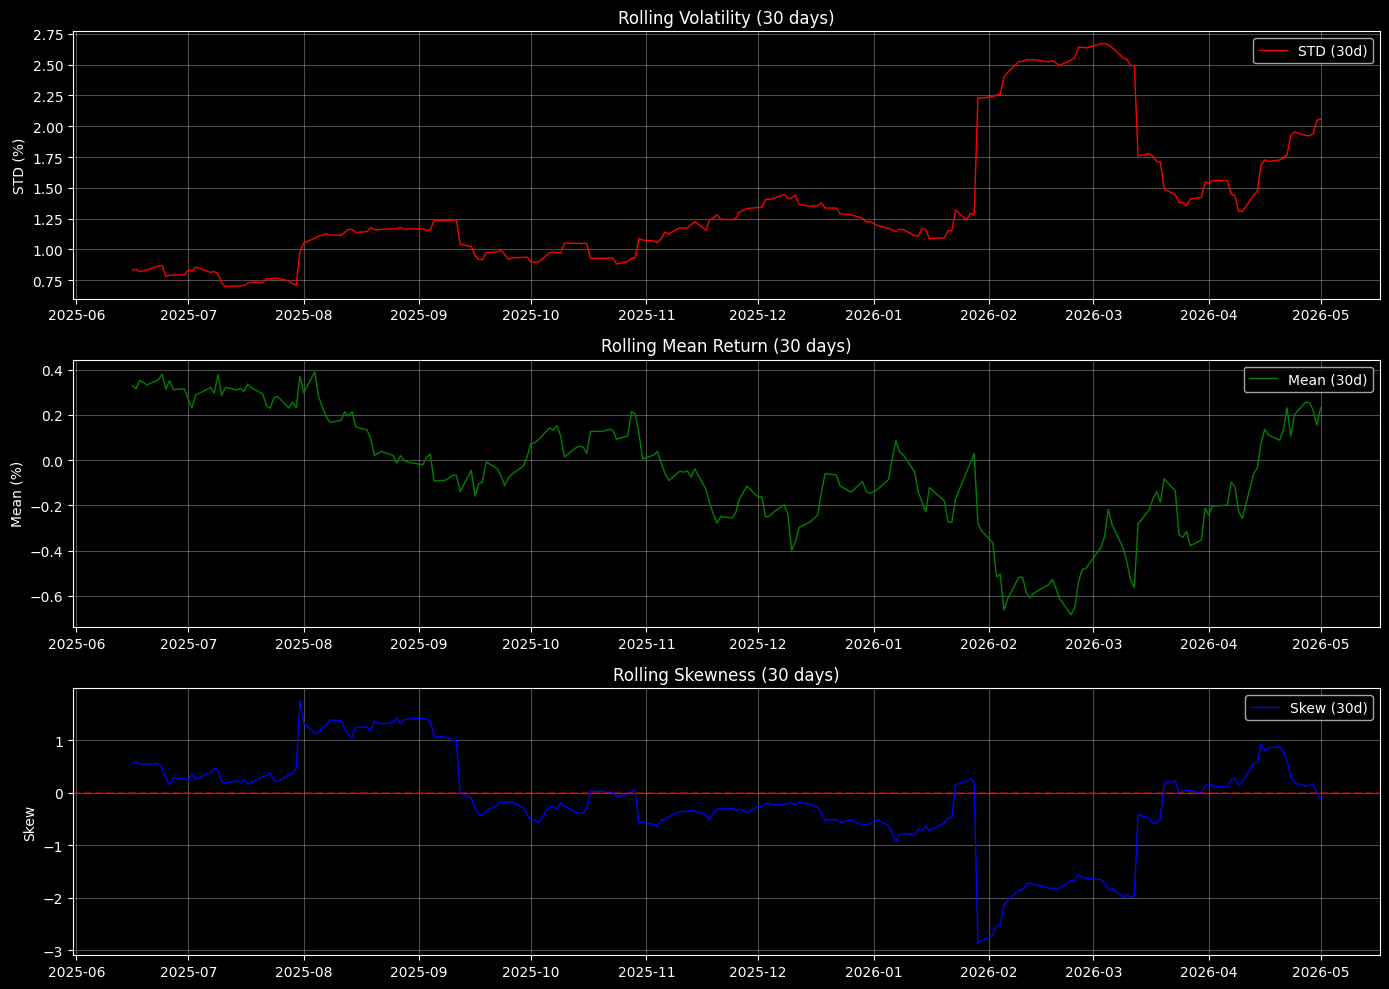

Plotting autocorrelation...


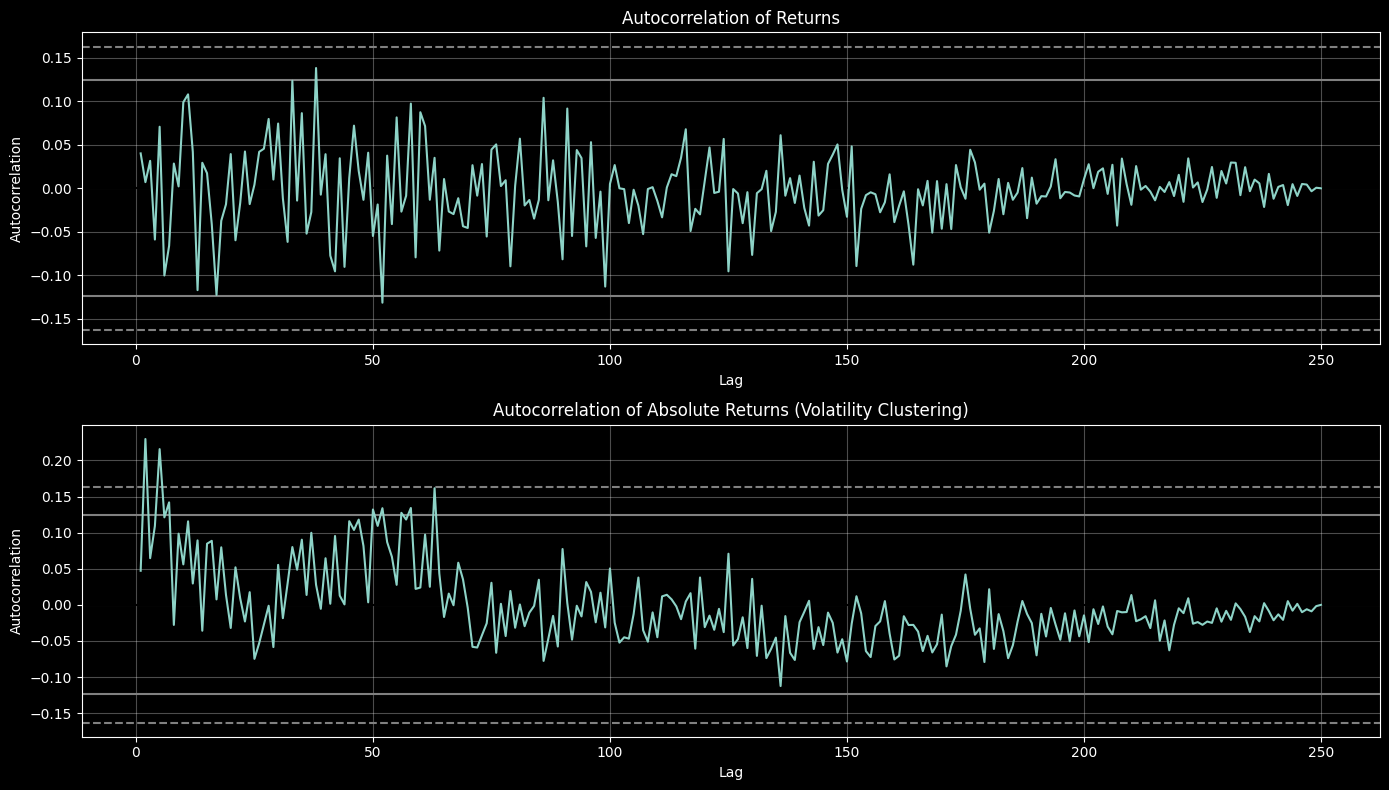


Outlier details (top 10):
Price         Return  Distance (STD)
Date                                
2026-01-29 -9.993146        6.716020
2026-02-05 -4.954247        3.327731
2026-04-15  4.606857        3.101408




In [34]:
results_msft = full_analysis(df_msft, 'MSFT', 30, 3)

In [45]:
# COMPARISON TABLE
comparison = pd.DataFrame({
    'AAPL': [results_aapl['stats']['std'], 
             results_aapl['stats']['skew'],
             results_aapl['stats']['kurt'],
             results_aapl['outlier_count']],
    'NVDA': [results_nvda['stats']['std'], 
             results_nvda['stats']['skew'],
             results_nvda['stats']['kurt'],
             results_nvda['outlier_count']],
    'MSFT': [results_msft['stats']['std'], 
             results_msft['stats']['skew'],
             results_msft['stats']['kurt'],
             results_msft['outlier_count']]
}, index=['STD', 'Skew', 'Kurtosis', 'Outliers'])

print('Comparison')
comparison.tail()

,AAPL,NVDA,MSFT
STD,1.472651,2.133844,1.487152
Skew,0.530566,0.118750,-1.275383
Kurtosis,2.307109,0.529379,8.331168
Outliers,3.000000,1.000000,3.000000
